# Linear Regression on the Hald Cement Data

In this example we use the Hald cement data [1](https://www.jstor.org/stable/2685561), a standard data set in the statistical literature. The data set measures several 13 different compositions of cement (see `data_x`), as well as the resulting _Heat of Hardening_ (see `data_y`). For further details on the data set, we refer to _Burnham and Anderson, chapter 3.2_ (including the numeric values).

The data set is known to exhibit colinearities in its four covariates. In this notebook will reduce the (linear) model by model selection.

## Data set

First we will read in the data set.

In [2]:
import numpy as np

# read in x
data_x = np.array(
    [
        [7, 26, 6, 60],
        [1, 29, 15, 52],
        [11, 56, 8, 20],
        [11, 31, 8, 47],
        [7, 52, 6, 33],
        [11, 55, 9, 22],
        [3, 71, 17, 6],
        [1, 31, 22, 44],
        [2, 54, 18, 22],
        [21, 47, 4, 26],
        [1, 40, 23, 34],
        [11, 66, 9, 12],
        [10, 68, 8, 12],
    ]
)

# read in y
data_y = np.array(
    [78.5, 74.3, 104.3, 87.6, 95.9, 109.2, 102.7, 72.5, 93.1, 115.9, 83.8, 113.3, 109.4]
)

## Define Model and Selection criterion.

and generate the (most general) Linear Model (here `LinearRegressionModel`, a wrapper around `sklearn.linear_model`) and the selection Criterion.

In [3]:
from modelSelector.model import LinearRegressionModel
from modelSelector.criterion import AIC, AIC_c, BIC, Mallows_Cp

# generate the full model, and fit it to data.
model = LinearRegressionModel('M_1111')
model.fit(data_x=data_x, data_y=data_y)

# criterion = Mallows_Cp(model)
# criterion = BIC()
criterion = AIC()

## Model selection

We will now go throught the different model selection methods. Most of the require a supermodel (e.g. `M_1111`), and consider all submodels of this model.

### Brute Force Search
Brute force is exhaustive, but takes time for larger scale models.

In [4]:
%%time
from modelSelector.selection_aglorithm.brute_force_search import brute_force_search

result_brute_force = brute_force_search(super_model=model, 
                                        criterion=criterion, 
                                        data_x=data_x, 
                                        data_y=data_y)

CPU times: user 17.1 ms, sys: 3.28 ms, total: 20.4 ms
Wall time: 20.8 ms


### Backward Search
Backwar search starts with the most complex model and iteratively eliminates the parameter, that leads to the largest improvement in criterion value. 

In [5]:
%%time
from modelSelector.selection_aglorithm.stepwise_search import backward_search, forward_search

result_backward_search_reduced = backward_search(super_model=model, 
                                                 criterion=criterion, 
                                                 exclude_before_fitting=True, 
                                                 data_x=data_x, 
                                                 data_y=data_y
                                                )

CPU times: user 9.5 ms, sys: 1.42 ms, total: 10.9 ms
Wall time: 11.2 ms


Note, that the `exlcude_before_fitting` flag is set to `True`. This means, that models, that can be excluded prior to fitting, are not fitted, which reduces the number of evaluated models.

In [6]:
%%time
result_backward_search_full = backward_search(super_model=model, 
                                              criterion=criterion, 
                                              exclude_before_fitting=False, 
                                              data_x=data_x, 
                                              data_y=data_y)

print("Number of fitted models, `exclude_before_fitting=True`:  "
      f"{result_backward_search_reduced.n_fitted_models}")
print("Number of fitted models, `exclude_before_fitting=False`: "
      f"{result_backward_search_full.n_fitted_models}")

Number of fitted models, `exclude_before_fitting=True`:  6
Number of fitted models, `exclude_before_fitting=False`: 8
CPU times: user 10.9 ms, sys: 1.64 ms, total: 12.6 ms
Wall time: 11.6 ms


### Forward Search
Forward search starts with the least general model and iteratively adds the parameter, that leads to the largest improvement in criterion value.

In [7]:
%%time
result_forward_search = forward_search(minimal_model=LinearRegressionModel('M_0000'), 
                                       criterion=criterion, 
                                       data_x=data_x, 
                                       data_y=data_y)
print("Number of fitted models, forward search: "
      f"{result_forward_search.n_fitted_models}")

Number of fitted models, forward search: 10
CPU times: user 14.2 ms, sys: 2.58 ms, total: 16.8 ms
Wall time: 15.9 ms


### Exhaustive Search
In the efficient exhaustive search algorithm, all models are either fitted, or can be excluded prior to fitting. Therefore this algorithm guarantees to find the best model, while it remains more effeient runtimes.

In [8]:
%%time
from modelSelector.selection_aglorithm.efficient_exhaustive_search import efficient_exhaustive_search

result_efficient_search = efficient_exhaustive_search(super_model=model, 
                                                      criterion=criterion, 
                                                      data_x=data_x, 
                                                      data_y=data_y)

print("Number of fitted models, efficient exhaustive seach: "
      f"{result_efficient_search.n_fitted_models}")

Number of fitted models, efficient exhaustive seach: 6
CPU times: user 8.72 ms, sys: 1.74 ms, total: 10.5 ms
Wall time: 9.06 ms


## Conclusion and Visualization

While all algorithms were able to find the best model `M_1101`, there are differences in the number of fitted models, and hence on runtime. Here our efficient exhaustive method needed 6.6% more model fits then the classical backward sarch, and 6.6% less then forwar search, while leading to a guaranteed optimal result.

|                       | forward | backward, classical | backward, reduced | efficient exhaustive | brute force |
|-----------------------|---------|----------|-------------------|----------------------|-------------|
| N. models fitted      | 10      | 8        | 6                 | 6                    | 15          |
| % models fitted       | 66.7    | 53.3     | 40.0              | 40.0                 | 100.0       |
| Found best model      | ✅      | ✅       | ✅               | ✅                   | ✅          |
| guaranteed optimality | ❌      | ❌       | ❌               | ✅                   | ✅         |

In [9]:
# check, if all models found the best model
for result in [result_forward_search, result_backward_search_full, result_backward_search_reduced, result_efficient_search, result_brute_force]:
    print(result.n_fitted_models)
    print(result.get_best_model())
    print('------------------------------')
# ToDo visualization

10
('M_1101', 646.619365813575)
------------------------------
8
('M_1101', 646.619365813575)
------------------------------
6
('M_1101', 646.619365813575)
------------------------------
6
('M_1101', 646.619365813575)
------------------------------
15
('M_1101', 646.619365813575)
------------------------------


In [10]:
for model in result_backward_search_full:
    if not result_backward_search_reduced[model]:
        print(model)
        
    

M_0101
M_1001


In [11]:
# model.fit(data_x, data_y)
from sklearn.linear_model import LinearRegression

m_sklearn = LinearRegression()
m_sklearn.fit(data_x, data_y)

LinearRegression()

In [13]:
model_best = result_brute_force.get_best_model()

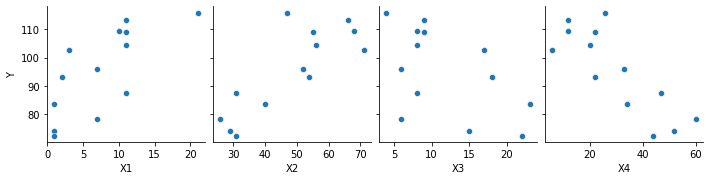

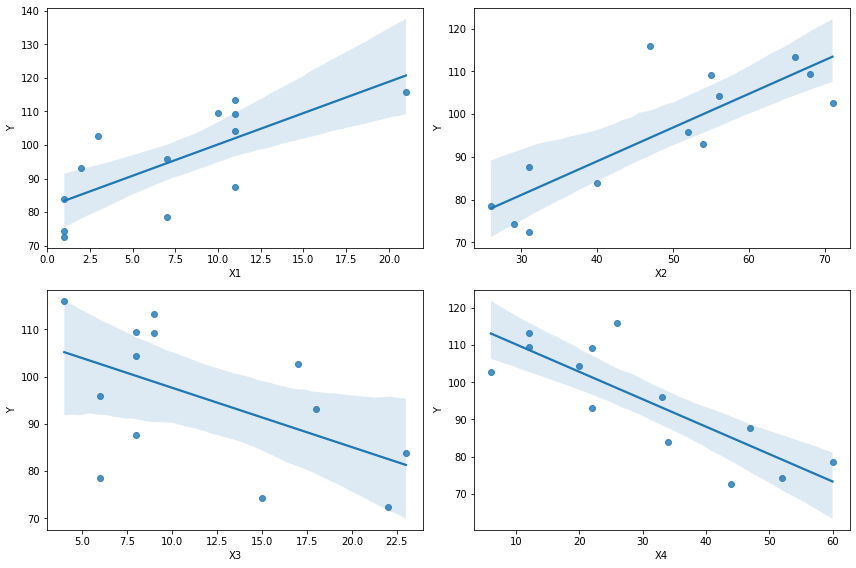

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame(np.column_stack((data_x, data_y)))
data.columns = ['X1', 'X2', 'X3', 'X4', 'Y']

# Pairplot
sns.pairplot(data, x_vars=['X1', 'X2', 'X3', 'X4'], y_vars=['Y'], kind='scatter')
plt.show()

# Regression Plots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

sns.regplot(x='X1', y='Y', data=data, ax=axes[0, 0])
sns.regplot(x='X2', y='Y', data=data, ax=axes[0, 1])
sns.regplot(x='X3', y='Y', data=data, ax=axes[1, 0])
sns.regplot(x='X4', y='Y', data=data, ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [44]:
model_opt = LinearRegressionModel('M_1011')
model_opt.fit(data_x=data_x, data_y=data_y)

In [45]:
data_modified = np.delete(data_x, 0, axis=1)
prediction = model_opt.model.predict(data_modified)

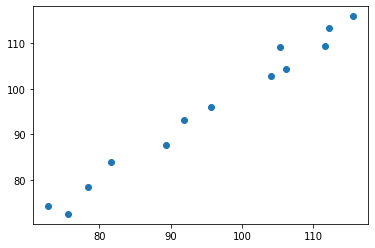

In [39]:
plt.plot(prediction, data_y, 'o')

In [46]:
prediction

array([ 98.00458482, 102.61212673, 154.45196889, 110.80011893,
       142.70828894, 151.70447913, 175.53853759, 106.98790109,
       146.96223522, 142.76867779, 122.47250669, 169.70283635,
       172.21658798])